# Trees

In [11]:
from IPython.display import Image
from IPython.display import SVG, display
from IPython.display import HTML

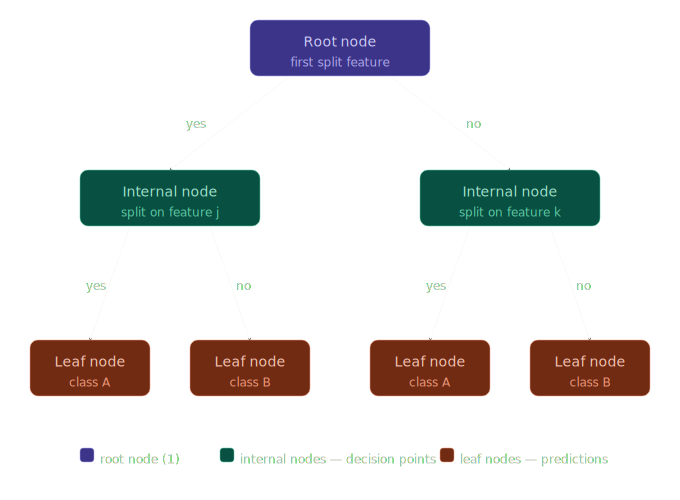

In [12]:
display(SVG(filename="../data/Trees/decision_tree_structure.svg"))

## Regression Trees

$$\hat{y} = f(x) = \sum_{m=1}^{M} c_m I(x \in R_m)$$

| Symbol | Meaning |
|--------|---------|
| $M$ | number of terminal leaves (or rectangles or nodes). Optimal $M$ is determined with a minimizing criterion. |
| $c_m$ | predicted value in terminal leaf $m$ (or rectangle $R_m$) |
| $I$ | indicator of whether a test observation falls into that terminal leaf |
| $x$ | p-dimensional vector |
| $R_m$ | a region that corresponds to leaf $m$ |

##### Fitting 
- Use **recursive binary splitting** to build a decision tree.
- **Recursive**:
  - At each node, solving the same problem as before. For example, "How do I best split this data?"
  - Instead of fitting a different algorithm for each level of the tree, write one splitting rule and call it repetitively on each resulting subset. 
- **Binary**:
  - At every node we ask one _yes, no_ question, and produce exactly 2 branches. 


### Prediction
$$ \text{RSS} = \sum^n_{i=1}(y_i-f(x_i))^2$$

- Best split is chosen across all variables and all vaues for each variable such that the residual sums of square (RSS) is minimized.
- Every leaf region, $R_m$, gets the same prediction; a single constant, $c_m$. Hence, $f(x_i) = c_m$ for all points in that leaf. 
$$\hat{c_m} = \text{ave}(y_i \space | \space x_i \in R_m)$$
- Similar to linear regression in a way that we fit the intercept-only model, such as $y=\beta_0+R; \space R \sim G(0, \sigma)$.
  - Minimizing RSS here: Use _least squares_. $\text{RSS} = \sum^n_{i=1}(y_i - f(x_i))^2$. 
  - Here, the _estimator_ ($\beta_0$) is the average; $\hat{\beta_0} = \bar{y}$. '
- In regression trees, we are fitting an itnercept-only model to every single leaf. 

$$\hat{y} = f(x) = \sum_{m=1}^{M} c_m I(x \in R_m)$$
- Since $x$ can only be in one region at a time, exactly one indicator term equals $1$ and the rest will be $0$, so the sum just collapses to a single $c_m$. 

### Best Split
- **Goal**: Split into 2 regions on variable $x_j$ and splitting value $s$. 
$$R_1(j,s) = \{X|X_j \leq s\}$$
$$R_2(j,s) = \{X|X_j > s\}$$
- Find variable $j$ and splitting value $s$ that minimizes:
$$\min_{j,s} \space [\min_{c1}\sum_{i:x_i \in R_1}(y_i-c_1)^2 + \min_{c2}\sum_{i:x_i \in R_2}(y_i-c_2)^2]\text{,}$$
$$\hat{c_1} = \text{ave}(y_i \ | \ x_i \in R_1)$$
$$\hat{c_2} = \text{ave}(y_i \ | \ x_i \in R_2)$$

:::{dropdown} Best Split Example
Best Split Example

| y  | x |
|----|---|
| 0  | 3 |
| -2 | 4 |
| 4  | 4 |
| 3  | 5 |
| 3  | 6 |

- Best split occurs at minimizing **RSS**.
- Does not matter exactly where you split between 2 $x$-values, we only consider _midpoints_.
  - The exact value of split threshold doesn't matter as long as it separates the same two groups. 
  - From the points above, try all midpoints between $(j,s)$. 
  - Between 3 and 4 → midpoint $s = 3.5$.
    - It doesn't matter if we choose $3.5, 3.1, 3.9$. For all the points, on the right side, there are $\{4,5,6\}$ and on the left side, there is $\{3\}$
  - Between 4 and 5 → midpoint $s = 4.5$
  - Between 5 and 6 → midpoint $s = 5.5$

- If we assume that $s = 3.5$:
  - $R_1(j,s) = \{X|X_j < 3.5\}$ = The only case that this falls onto is when $(3,0)$ with $x=3$. Hence, $\text{RSS} = (0-0)^2$.
  - $R_1(j,s) = \{X|X_j > 3.5\}$:
    - Computing $c_m$: $\frac{(-2) + 4+ 3+3}{4} = 2$.
  - $\text{RSS } = \sum^n_{i=1}(y_i-f(x_i))^2 = (-2-2)^2 + (4-2)^2 + (3-2)^2 + (3-2)^2 = 22$.

- Try multiple $s$, and the one with the lowest **RSS** is the best split.  

#### Process for Best Split
1. Try every possible split between $(j,s)$. 
2. Compute RSS for left side and rigt side of the split
- $R_1(j,s) = \{X|X_j < s\}$
- $R_2(j,s) = \{X|X_j > s\}$
3. Compute prediction in each region by taking $\bar{y}$
4. Calculate $\text{RSS} = \sum (y_i - \bar{y})^2$
:::

- When there are multiple leaves in a tree, we need a way to decide which leaf to split next on which variable. To do so, measure the **reduction** in SS that each possible split can give you.
  - It puts all splits on a comparable scale regardless of leaf size, so you're always making the single most impactful split available.

### Stopping Criterion


- When should a tree be stopped growing to avoid _overfitting_?

##### Options
1. (Less preferred) Split only if the split reduces the residual sum of squares (RSS) by at least some threshold value.
2. Over-build the tree and _prune_ the tree later. 
3. Minimum observations.
  - Set a threshold that is defined by a number of observations that must be contained in each leaf. 
  - **Having less number of observations**: High variance (increases the risk of overfitting)and bad bias/variance tradeoff. 

### Tree Pruning
Pruning
: After builidng on overly large tree, remove leaves that do not substantially improve classification or regression.
- After a tree is fully extended, remove one split at a time to minimize this criterion:
$$\sum_{m=1}^{|T|} \sum_{i:\, x_i \in R_m} \left( y_i - \hat{y}_{R_m} \right)^2 + \alpha |T|, \quad \alpha \ge 0$$

| Concept        | Description                                             |
|----------------|---------------------------------------------------------|
| \|$T$\|         | Number of leaves in the tree                            |
| $\alpha$ \|$T$\|  | Penalty for having too many leaves                      |
| $\alpha$       | Tuning parameter, chosen via cross-validation            |
| $m$       | Indexes leaves          |
| $i$       | Indexes observations within a given leaf          |

- **Larger** tree has less bias but more variance (overfitting).
- **Smaller** tree has more bias but less variance (overfitting).
- $\alpha$ is a regularization term that regulates bias-variance tradeoff. 

### Non-Continuous $x$-Variables
#### Ordinal Values
- Assign numerical value (levels) to each terms.
- _E.g.,_ <"high scool", "some college", "college"> as $1,2,3$ and treat it as continuous variables.
- As long as the order is maintained, it doesn't matter what value is actually getting used. Hence, spacing between categories is made up, and can be ignored in tree models.
  - This cannot be done for **linear models** who assume that the relationship is perfectly linear. 
  - The coefficient $\beta$ gets multiplied by the coded value directly, and a value of $2$ has exactly twice the effect of $1$. 

#### Indicator Variables
Indicator Variable
: Variables that only take $0$ or $1$. 

- Only allows a single split. 
- Split point is always $0.5$, given the indicator variable is coded as either $0$ or $1$. 

#### Categorical Nominal Variables
- Some categories can be split off. 
- _E.g.,_ "Hispanic", "White", "African American", "Asian" in `race` $x$-variable. 
1. **Option 1**: SPlit into 2 subsets, such as "White", "African American" and "Hispanic", "Asian" based on similiar outcomes. 
2. **Option 2**: One vs. Rest. Split off a single category from a set of categories.


## Classification Trees
### Prediction
$$\max_k(\hat{p_{mk}})$$
- Prediction is made on the most frequently occurring class for a given leaf. 
- $\hat{p}_{mk}$ is the proportion of training points in the leaf $m$ that belongs to class $k$. Used to measure how _pure_ a leaf is. A pure leaf has all points belonging to one class.
- _E.g.,_
  - $P(\text{history} | \text{leaf}) = \frac{1}{2}$
  - $P(\text{comedy}|\text{leaf}) = \frac{1}{3}$
  - $P(\text{tragedy}|\text{leaf}) = \frac{1}{6}$
  - In this case, predicted value is _history_. 

### Minimization Criterion
- RSS cannot be used anymore. 
- Alternative criterias used:

| Measure | Formula | What it means |
|---|---|---|
| Classification error | $E = 1 - \max_k(\hat{p}_{mk})$ | Fraction of points in the leaf that aren't the majority class. |
| Gini index | $G = \sum_{k=1}^{K} \hat{p}_{mk}(1 - \hat{p}_{mk})$ | Probability of misclassifying a randomly chosen point in the leaf |
| Entropy | $D = -\sum_{k=1}^{K} \hat{p}_{mk} \log \hat{p}_{mk}$ | Amount of disorder/uncertainty in the leaf |
 
- $k$ = indexes outcomes, $m$ = indexes leaves.

Pure Node
: A node is _pure_ if all observations in it belong to the same class. 

:::{dropdown} Splitting Criterion Example
Assume $k$=2 with two classes, $n$=1000 observations, and $500$ observations in each class. 
Recall $\hat{p}_{mk}$ = The proportion of points in leaf $m$ that belongs to class $k$. 
$$\hat{p}_{m,k} = \frac{\text{Number of class } k \text{ points in leaf } m}{\text{Total points in leaf } m}$$

Consider the **first split case** with two leaves with $(400,100)$ and $(100,400)$. 
$(400,100)$ means that $400$ points are in class $1$, and $100$ points are class $2$ in that leaf.

<img src="../data/Trees/classification-tree.png" style="display:block;margin:auto"/>

- $\hat{p}_{1,1} = \frac{400}{500} = 0.8$
- $\hat{p}_{1,2} = \frac{100}{500} = 0.2$
- $\hat{p}_{2,1} = \frac{100}{500} = 0.2$
- $\hat{p}_{2,2} = \frac{400}{500} = 0.8$
- Predicted class for $m_1$ is $1$, and $m_2$ is $2$. 

**Computing Error**
- **Classification error** only looks at the predicted class. 
  - Misprediction from $m_1$ = 100, $m_2$ = 100. Thus, $\frac{200}{1000} = 0.2$.
- Recall, **Gini Index**: $G = \sum_{k=1}^{K} \hat{p}_{mk}(1 - \hat{p}_{mk})$. 
- With that, weights for each _leaf_ is proportional to the number of observations in the leaf. 
- $0.5\times[(0.8 \times 0.2) + (0.2 \times 0.8)] + 0.5[(0.2 \times 0.8) + (0.8 \times 0.2)] = 0.32$

Now consider **second split case** with two leaves with $(200,500)$ and $(300,0)$. 

<img src="../data/Trees/classification-tree2.png" style="display:block;margin:auto"/>

- $\hat{p}_{1,1} = \frac{200}{700} = 0.286$
- $\hat{p}_{1,2} = \frac{500}{700} = 0.714$
- $\hat{p}_{2,1} = \frac{300}{300} = 1.0$
- $\hat{p}_{2,2} = \frac{0}{0} = 0$
- Predicted class for $m_1$ is $2$, and $m_2$ is $1$. 
- Here, $(300,0)$ is a perfectly pure node.

**Computing Error**
- **Classification error** only looks at the predicted class. 
  - Misprediction from $m_1$ = 200, $m_2$ = 0. Thus, $\frac{200}{1000} = 0.2$.
- $0.7\times[(0.286 \times 0.714) + (0.714 \times 0.286)] + 0.3[(1.0 \times 0) + (0 \times 1.0)] = 0.286$

##### Result
- When comparing based on **Gini index**, it prefers the purer split, 2 as it minimizes $G$. 
- Both Gini and Deviance assumes that the leaf is more pure if resulting value is smaller. They are more sensitive to _node purity_ compared to classification error. 

:::

## Usage
- Can capture non-linear relationships.
- Can be highly interpretable.
- Invariant to outliers, since trees only use ordering of values for splits.
- Easy handling of missing data.
- Can capture feature interactions naturally without needing _interaction terms._
- Can use mixed data types. 

## Limitations
- Not useful for linear relationships.
- Not useful for small datasets as leaves become too small and unstable.
- Not very good at prediction.
- A single tree has _high variance_ and can be destabilized by small changes in data. 
- Highly unstable to perturbations of training data. 
  - Cannot be extrapolated beyond the range of training data.

::::{grid} 2
:::{grid-item}
:class: text-center
{button}`School Notes <../school-notes/Trees.pdf>`
:::
:::{grid-item}
:class: text-center
{button}`Solutions Key <../solution/kNN.pdf>`
:::
::::